In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]
T_end = 15.0
M_vec = [6, 7]

x_lower = 0.0; x_upper = 12.566370614359172
base_tree_level = 6
polydeg = 3

epsilon = 0.001
k = [0.5]#!, 0.4, 0.3, 0.2]

M=6, k=0.5


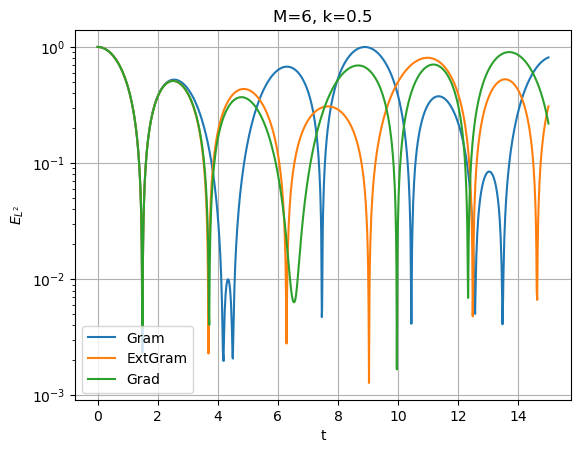

M=7, k=0.5


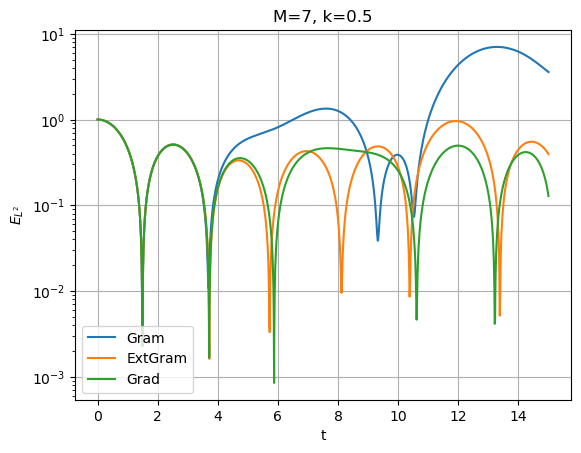

In [9]:
for M in M_vec:
    for k_ in k:
        i = k.index(k_)
        print(f"M={M}, k={k_}")

        plt.figure()
        for closure in closures:
            file = f"../out/VlasovPoisson/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
            data = pd.read_csv(file)

            plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=closure)

        plt.yscale("log")
        plt.xlabel("t")
        plt.ylabel("$E_{L^2}$")
        plt.title(f"M={M}, k={k_}")
        plt.legend(loc='lower left')
        plt.grid()
        plt.savefig(f"../out/VlasovPoisson/LandauDamping_M{M}_k{k_}_epsilon{epsilon}_p{polydeg}.pdf")
        plt.show()

In [10]:
T_end = 15.0

base_tree_level = 6
polydeg = 1

epsilon = 0.001
k = 0.5

<>:41: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\c'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_7926/4165666080.py:41: SyntaxWarning: invalid escape sequence '\c'
  ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_7926/4165666080.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_E.show()


Recursion times
----------------
M=4: t_rec=0.48
M=6: t_rec=0.48
M=8: t_rec=0.48
M=10: t_rec=5.129237417126821
M=12: t_rec=6.235915037143205
Recursion times
----------------
M=4: t_rec=0.48
M=6: t_rec=0.48
M=8: t_rec=5.757318504328638
M=10: t_rec=8.964203674040366
M=12: t_rec=8.31


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_7926/4165666080.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_E.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_7926/4165666080.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_recursion.show()


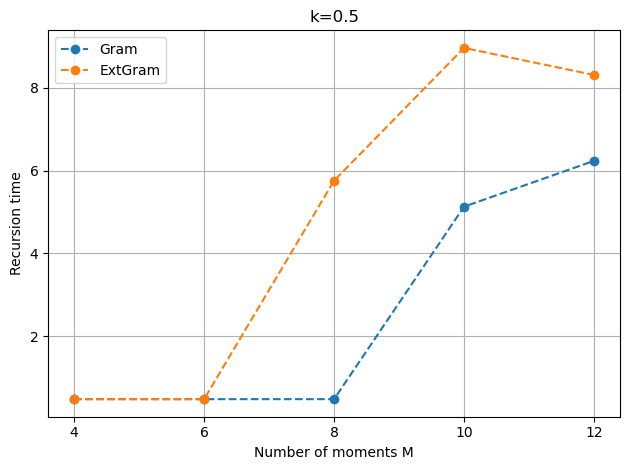

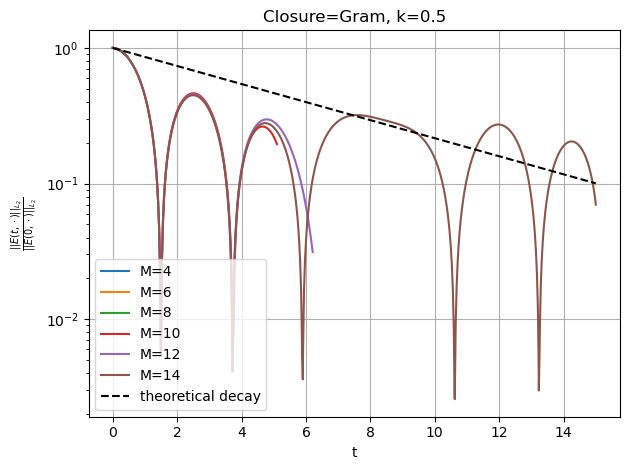

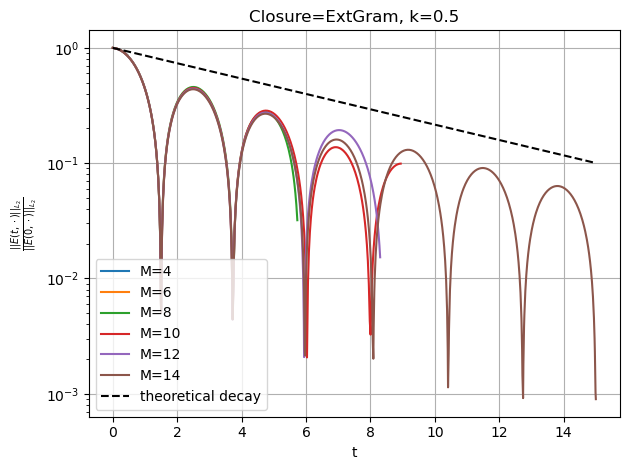

In [11]:
# Even Order Moments

closures = [
    "Gram",
    "ExtGram"
]
M_vec = [4, 6, 8, 10, 12, 14]

# recursion time
rel_tol = 0.1
gamma = -0.1533  # theoretical damping rate for k=0.5
# reference solution
# Todo: Compare with Grad?
file = f"../out/VlasovPoisson/energy_moments_closureExtGram_T{T_end}_M{M_vec[-1]}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
data = pd.read_csv(file)
E_ref = data["E_L2"].to_numpy() / data["E_L2"][0]

fig_recursion, ax_recursion = plt.subplots()
for closure in closures:
    recursion_time = []
    fig_E, ax_E = plt.subplots()
    for M in M_vec:

        file = f"../out/VlasovPoisson/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)
        # plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')

        # recursion time: time until which the solution is accurate
        if M != M_vec[-1]:
            E_num = data["E_L2"].to_numpy() / data["E_L2"][0]
            for t_idx in range(len(E_num)):
                if (E_ref[t_idx] - E_num[t_idx]) * np.exp(-gamma * data["time"][t_idx]) > rel_tol:
                    recursion_time.append(data["time"][t_idx])
                    ax_E.plot(data["time"][:4//3*t_idx], data["E_L2"][:4//3*t_idx] / data["E_L2"][0], label=f'M={M}')
                    break
        else:
            ax_E.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
            ax_E.plot(data["time"], np.exp(gamma * data["time"]), "k--", label="theoretical decay")
    ax_E.set_yscale("log")
    ax_E.set_xlabel("t")
    ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    ax_E.set_title(f"Closure={closure}, k={k}")
    ax_E.legend(loc='lower left')
    ax_E.grid()
    fig_E.savefig(f"../out/VlasovPoisson/LandauDamping_Even_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig_E.tight_layout()
    fig_E.show()

    print("Recursion times")
    print("----------------")
    for i, M in enumerate(M_vec[:-1]):
        print(f"M={M}: t_rec={recursion_time[i]}")

    ax_recursion.plot(M_vec[:-1], recursion_time, "o--", label=f"{closure}")
ax_recursion.set_xlabel("Number of moments M")
ax_recursion.set_ylabel("Recursion time")
ax_recursion.set_xticks(M_vec[:-1])
ax_recursion.set_title(f"k={k}")
ax_recursion.legend()
ax_recursion.grid()
fig_recursion.savefig(f"../out/VlasovPoisson/LandauDamping_RecursionTime_Even_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig_recursion.tight_layout()
fig_recursion.show()

<>:41: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\c'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_7926/3335178932.py:41: SyntaxWarning: invalid escape sequence '\c'
  ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_7926/3335178932.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_E.show()


Recursion times
----------------
M=5: t_rec=0.48
M=7: t_rec=0.48
M=9: t_rec=0.48
M=11: t_rec=6.42
M=13: t_rec=11.575904010802152
Recursion times
----------------
M=5: t_rec=0.48
M=7: t_rec=5.518101568994179
M=9: t_rec=6.45
M=11: t_rec=8.51237440672016
M=13: t_rec=7.700537254306058


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_7926/3335178932.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_E.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_7926/3335178932.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_recursion.show()


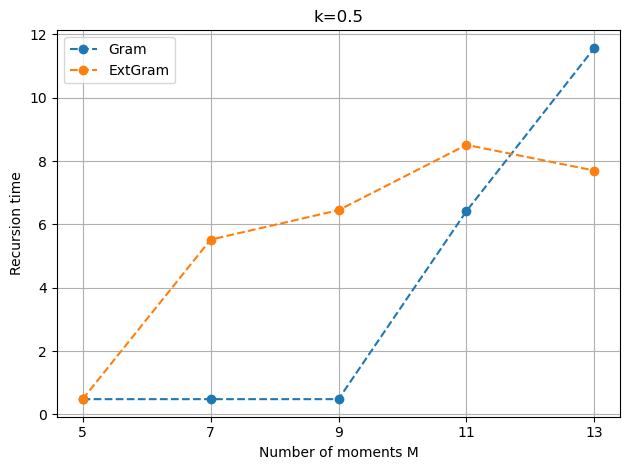

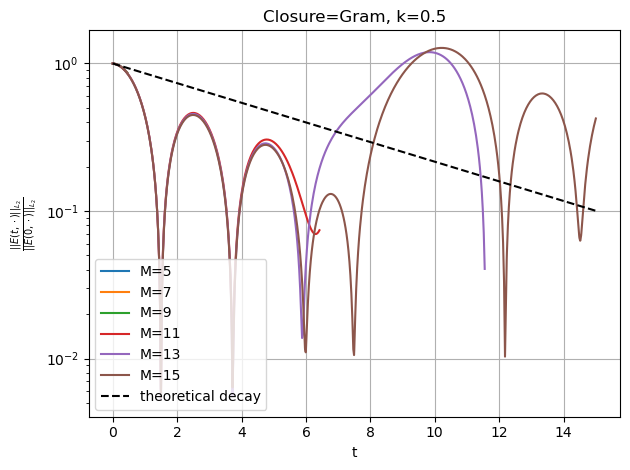

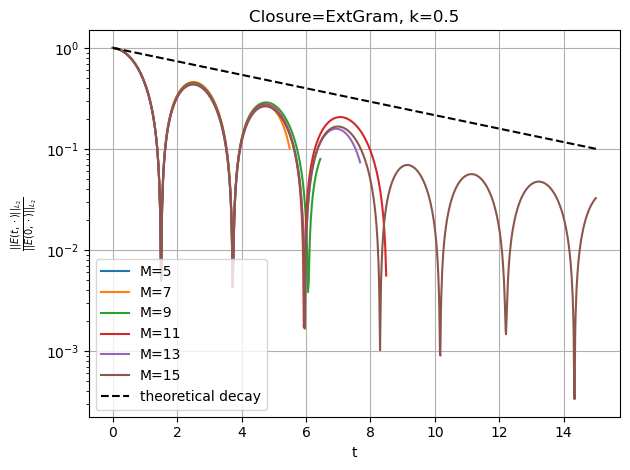

In [12]:
# Odd Order Moments

closures = [
    "Gram",
    "ExtGram"
]
M_vec = [5, 7, 9, 11, 13, 15]

# recursion time
rel_tol = 0.1
gamma = -0.1533  # theoretical damping rate for k=0.5
# reference solution
# Todo: Compare with Grad?
file = f"../out/VlasovPoisson/energy_moments_closureExtGram_T{T_end}_M{M_vec[-1]}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
data = pd.read_csv(file)
E_ref = data["E_L2"].to_numpy() / data["E_L2"][0]

fig_recursion, ax_recursion = plt.subplots()
for closure in closures:
    recursion_time = []
    fig_E, ax_E = plt.subplots()
    for M in M_vec:

        file = f"../out/VlasovPoisson/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)
        # plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')

        # recursion time: time until which the solution is accurate
        if M != M_vec[-1]:
            E_num = data["E_L2"].to_numpy() / data["E_L2"][0]
            for t_idx in range(len(E_num)):
                if (E_ref[t_idx] - E_num[t_idx]) * np.exp(-gamma * data["time"][t_idx]) > rel_tol:
                    recursion_time.append(data["time"][t_idx])
                    ax_E.plot(data["time"][:4//3*t_idx], data["E_L2"][:4//3*t_idx] / data["E_L2"][0], label=f'M={M}')
                    break
        else:
            ax_E.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
            ax_E.plot(data["time"], np.exp(gamma * data["time"]), "k--", label="theoretical decay")
    ax_E.set_yscale("log")
    ax_E.set_xlabel("t")
    ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    ax_E.set_title(f"Closure={closure}, k={k}")
    ax_E.legend(loc='lower left')
    ax_E.grid()
    fig_E.savefig(f"../out/VlasovPoisson/LandauDamping_Odd_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig_E.tight_layout()
    fig_E.show()

    print("Recursion times")
    print("----------------")
    for i, M in enumerate(M_vec[:-1]):
        print(f"M={M}: t_rec={recursion_time[i]}")

    ax_recursion.plot(M_vec[:-1], recursion_time, "o--", label=f"{closure}")
ax_recursion.set_xlabel("Number of moments M")
ax_recursion.set_ylabel("Recursion time")
ax_recursion.set_xticks(M_vec[:-1])
ax_recursion.set_title(f"k={k}")
ax_recursion.legend()
ax_recursion.grid()
fig_recursion.savefig(f"../out/VlasovPoisson/LandauDamping_RecursionTime_Odd_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig_recursion.tight_layout()
fig_recursion.show()